<a href="https://colab.research.google.com/github/tatahonon/cvNotebooks/blob/main/Homework62.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Prac 06.2

In this homework, you are going to use and compare two different trackers (of your liking) and compare the results.

### Step 1
Decide what video you are going to use for this homework, select an object and generate the template. You can use any video you want (your own, from Youtube, etc.)
and track any object you want (e.g. a car, a pedestrian, etc.).

### Step 2
Initialize a tracker (e.g. KCF).

### Step 3
Run the tracker on the video and the selected object. Run the tracker for around 10-15 frames.

### Step 4
For each frame, print the bounding box on the image and save it.

### Step 5
Select a different tracker (e.g. CSRT) and repeat steps 2, 3 and 4.

### Step 6
Compare the results:
* Do you see any differences? If so, what are they?
* Does one tracker perform better than the other? In what way?

In [5]:

!wget https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/vid62.mp4

--2026-05-22 13:26:51--  https://raw.githubusercontent.com/tatahonon/cvNotebooks/main/vid62.mp4
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 12009981 (11M) [application/octet-stream]
Saving to: ‘vid62.mp4.1’

vid62.mp4.1         100%[===================>]  11.45M  --.-KB/s    in 0.03s   

2026-05-22 13:26:51 (438 MB/s) - ‘vid62.mp4.1’ saved [12009981/12009981]



In [6]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Download frames: 16


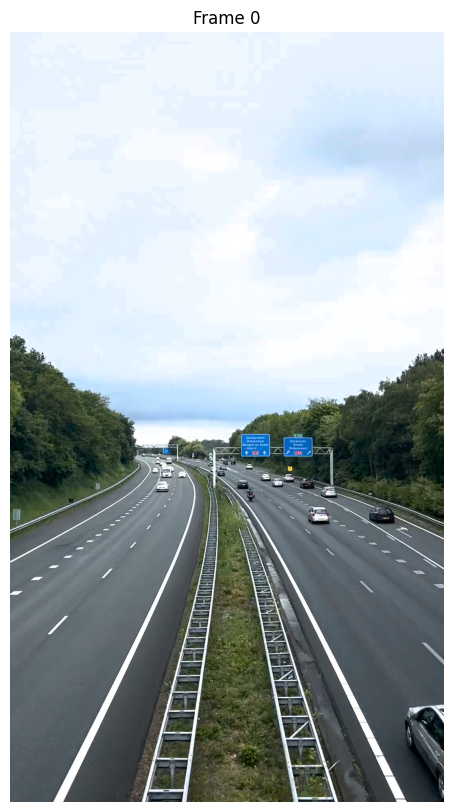

In [7]:
video = cv2.VideoCapture('/content/vid62.mp4')

frames = []
while True:
    ret, frame = video.read()
    if not ret:
        break
    frames.append(frame)
video.release()

frames = frames[:16]
print(f'Download frames: {len(frames)}')

plt.imshow(cv2.cvtColor(frames[0], cv2.COLOR_BGR2RGB))
plt.title('Frame 0')
plt.axis('off')
plt.show()

In [8]:
bbox = (620, 510, 120, 80)

tracker_kcf = cv2.TrackerKCF_create()
tracker_kcf.init(frames[0], bbox)

In [9]:
kcf_results = []

for i in range(1, len(frames)):
    success, box = tracker_kcf.update(frames[i])
    result = frames[i].copy()
    if success:
        x, y, w, h = [int(v) for v in box]
        cv2.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 2)
        cv2.putText(result, f'KCF {i}', (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    else:
        cv2.putText(result, 'KCF: Lost', (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

    kcf_results.append(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    cv2.imwrite(f'/content/kcf_frame_{i}.jpg', result)

print('KCF done')

KCF done


In [10]:
config_st = {'maxCorners': 100, 'qualityLevel': 0.3,
             'minDistance': 7, 'blockSize': 7}
config_lk = {'winSize': (15, 15), 'maxLevel': 2,
             'criteria': (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)}

src_gray = cv2.cvtColor(frames[0], cv2.COLOR_BGR2GRAY)
x, y, w, h = bbox
mask_roi = np.zeros_like(src_gray)
mask_roi[y:y+h, x:x+w] = 255

p_src = cv2.goodFeaturesToTrack(src_gray, mask=mask_roi, **config_st)
color = np.random.randint(0, 255, (100, 3))

lk_results = []

for i in range(1, len(frames)):
    dst_gray = cv2.cvtColor(frames[i], cv2.COLOR_BGR2GRAY)

    p_dst, status, err = cv2.calcOpticalFlowPyrLK(src_gray, dst_gray, p_src, None, **config_lk)

    result = frames[i].copy()
    draw_mask = np.zeros_like(frames[0])

    if p_dst is not None and status is not None:
        good_dst = p_dst[status == 1]
        good_src = p_src[status == 1]

        for j, (dst, src) in enumerate(zip(good_dst, good_src)):
            pt_dst = (int(dst[0]), int(dst[1]))
            pt_src = (int(src[0]), int(src[1]))
            c = color[j].tolist()
            cv2.arrowedLine(draw_mask, pt_src, pt_dst, c, 2, tipLength=0.5)
            cv2.circle(result, pt_dst, 5, c, -1)

        p_src = good_dst.reshape(-1, 1, 2)
        src_gray = dst_gray

    result = cv2.add(result, draw_mask)
    cv2.putText(result, f'LK {i}', (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 0), 2)

    lk_results.append(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    cv2.imwrite(f'/content/lk_frame_{i}.jpg', result)

print('Lucas-Kanade done')

Lucas-Kanade done


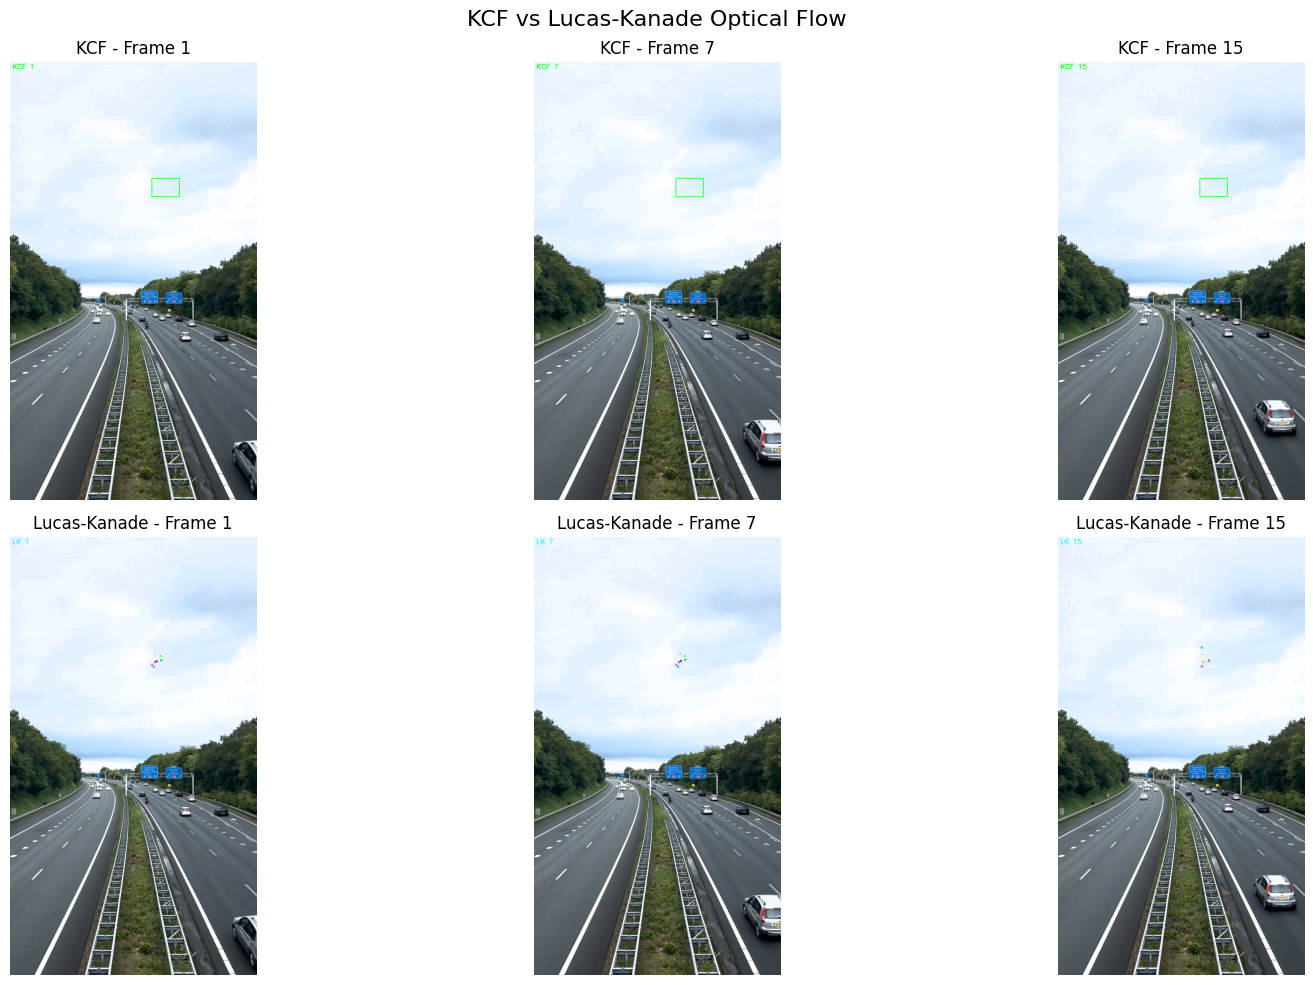

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, idx in enumerate([0, 6, 14]):
    axes[0, i].imshow(kcf_results[idx])
    axes[0, i].set_title(f'KCF - Frame {idx+1}')
    axes[0, i].axis('off')

    axes[1, i].imshow(lk_results[idx])
    axes[1, i].set_title(f'Lucas-Kanade - Frame {idx+1}')
    axes[1, i].axis('off')

plt.suptitle('KCF vs Lucas-Kanade Optical Flow', fontsize=16)
plt.tight_layout()
plt.show()